In [16]:
import pandas as pd

In [17]:
df = pd.read_csv("/content/Salary Data (1).csv")

In [18]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [28]:
df.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [29]:
numerical_cols = ['Age', 'Years of Experience', 'Salary']
for col in numerical_cols:
    mean_val = df[col].mean()
    df[col] = df[col].fillna(mean_val)

In [30]:
display(df.isnull().sum())

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [31]:
categorical_cols = ['Gender', 'Education Level', 'Job Title']
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

In [32]:
display(df.isnull().sum())

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [33]:
from sklearn.preprocessing import LabelEncoder

In [34]:
label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [36]:
display(df.head())

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0


In [37]:
from sklearn.model_selection import train_test_split

In [42]:
X = df.drop("Salary", axis=1)
y = df["Salary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state =42)

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'SVM': SVR(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'KNN': KNeighborsRegressor(),
    'Random Forest': RandomForestRegressor(random_state=42)
}

results = {}

### Model Training and Evaluation

In [47]:
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results[name] = {'R-squared': r2, 'MAE': mae, 'MSE': mse}

    print(f"{name} R-squared: {r2:.4f}")
    print(f"{name} MAE: {mae:.2f}")
    print(f"{name} MSE: {mse:.2f}")


--- Training Linear Regression ---
Linear Regression R-squared: 0.8981
Linear Regression MAE: 10744.50
Linear Regression MSE: 246873399.55

--- Training SVM ---
SVM R-squared: -0.0171
SVM MAE: 40732.11
SVM MSE: 2463974313.39

--- Training Decision Tree ---
Decision Tree R-squared: 0.9067
Decision Tree MAE: 10133.33
Decision Tree MSE: 226000000.00

--- Training KNN ---
KNN R-squared: 0.8653
KNN MAE: 11899.49
KNN MSE: 326224545.21

--- Training Random Forest ---
Random Forest R-squared: 0.9258
Random Forest MAE: 9532.88
Random Forest MSE: 179735869.86


### Summary of Model Performance

In [48]:
import pandas as pd
display(pd.DataFrame(results).T)

,R-squared,MAE,MSE
Linear Regression,0.898091,10744.500972,2.468734e+08
SVM,-0.017122,40732.109102,2.463974e+09
Decision Tree,0.906708,10133.333333,2.260000e+08
KNN,0.865335,11899.491689,3.262245e+08
Random Forest,0.925806,9532.881696,1.797359e+08


### Visualizing Model Performance

/tmp/ipykernel_2946/3871096870.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='R-squared', data=results_df, palette='viridis')


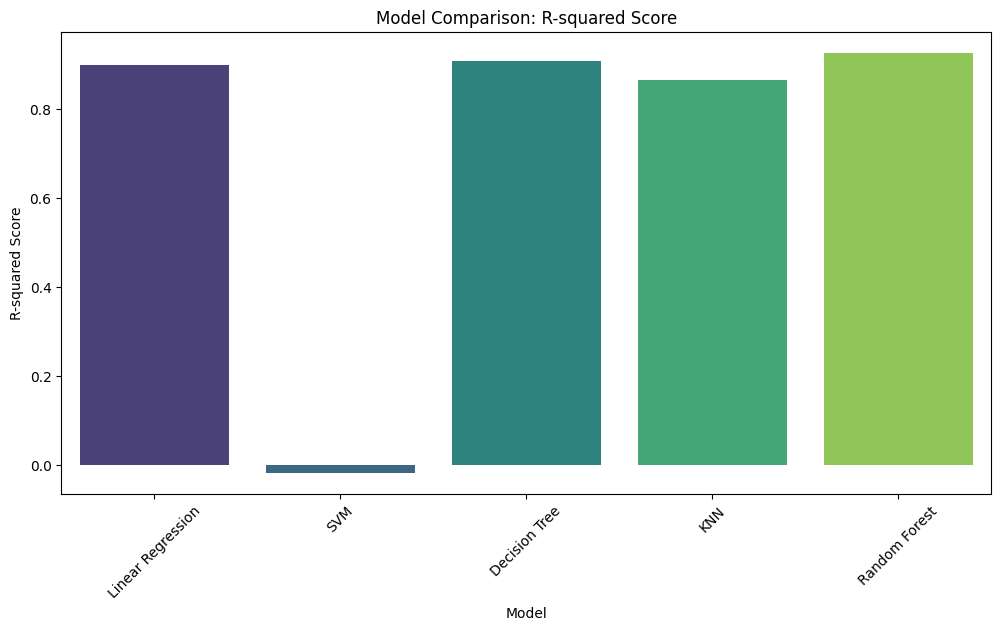

/tmp/ipykernel_2946/3871096870.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='MAE', data=results_df, palette='magma')


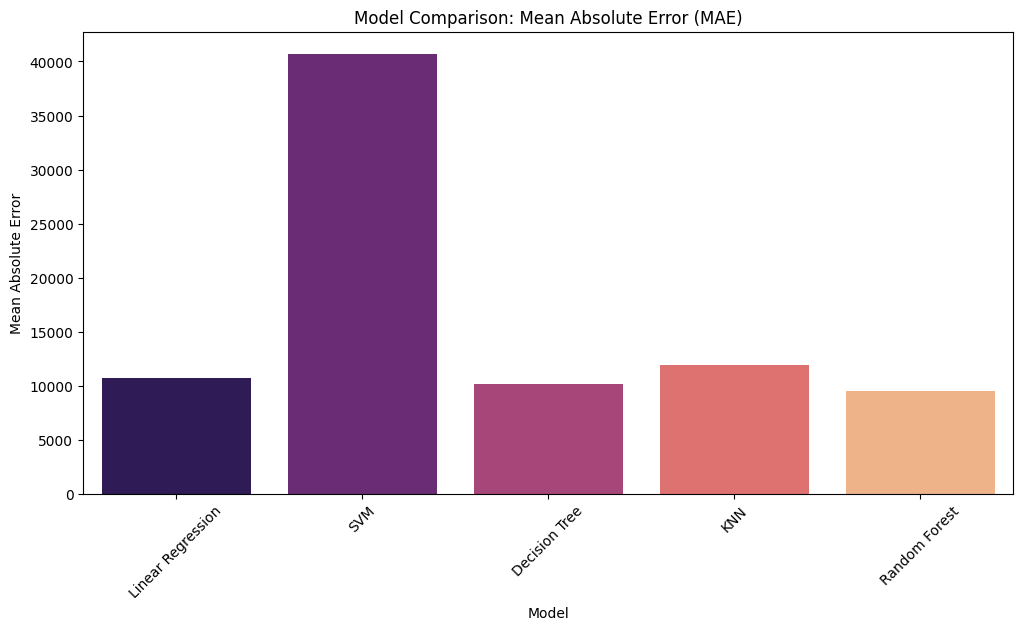

/tmp/ipykernel_2946/3871096870.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='MSE', data=results_df, palette='plasma')


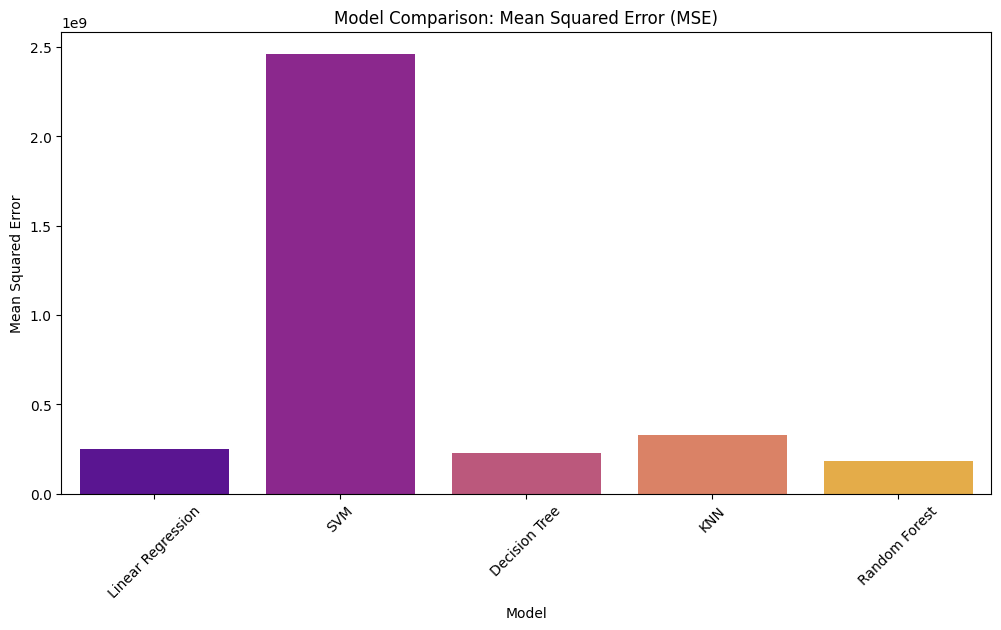

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

results_df = pd.DataFrame(results).T

# Plot R-squared
fig1 = plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y='R-squared', data=results_df, palette='viridis')
plt.title('Model Comparison: R-squared Score')
plt.ylabel('R-squared Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.show()

# Plot MAE
fig2 = plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y='MAE', data=results_df, palette='magma')
plt.title('Model Comparison: Mean Absolute Error (MAE)')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.show()

# Plot MSE
fig3 = plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y='MSE', data=results_df, palette='plasma')
plt.title('Model Comparison: Mean Squared Error (MSE)')
plt.ylabel('Mean Squared Error')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.show()

In [57]:
import joblib

# Identify the best model based on R-squared from the results
best_model_name = results_df['R-squared'].idxmax()
best_model = models[best_model_name]

# Save the best model to a .pkl file
model_filename = 'best_model.pkl'
joblib.dump(best_model, model_filename)

print(f"The best model ({best_model_name}) has been saved as '{model_filename}'")

The best model (Random Forest) has been saved as 'best_model.pkl'


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [50]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [51]:
pred = model.predict(X_test)


In [52]:
print("MSE:", mean_squared_error(y_test, pred))


MSE: 246873399.55118892


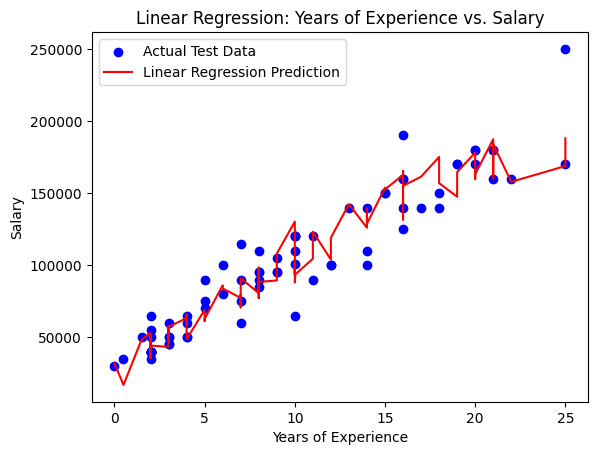

In [54]:
import numpy as np

# Select 'Years of Experience' from X_test for plotting
x_plot_test = X_test['Years of Experience']

# Sort the x-values and predictions for a smooth line
sort_indices = np.argsort(x_plot_test)
x_plot_test_sorted = x_plot_test.iloc[sort_indices]
pred_sorted = pred[sort_indices]

# Plot actual values from X_test and y_test
plt.scatter(x_plot_test, y_test, color='blue', label='Actual Test Data')

# Plot the linear regression line
plt.plot(x_plot_test_sorted, pred_sorted, color='red', label='Linear Regression Prediction')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression: Years of Experience vs. Salary")
plt.legend()
plt.show()